# Dropout is A form of Variable Neighborhood Search

Prof. Wenbin Zhu (i@zhuwb.com)
School of Business Administration,
South China University of Technology
Date: 24 Jul 2020


The full network $N_3$ is given by:
$$ f(\mathbf{x_i},\mathbf{w}) = w_1 x_{i1} + w_2 x_{i2} $$


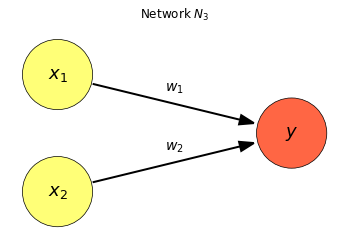

In [1]:
try:
    import viznet
except:
    !pip install viznet
    import viznet
    
def plotN3():
    # https://viznet.readthedocs.io/en/latest/tutorials.html
    from viznet import NodeBrush, EdgeBrush
    
    brushIn = NodeBrush('nn.input', size='normal')
    brushOut = NodeBrush('nn.output', size='normal')

    n_x1 = brushIn >> (1,2)
    n_x1.text("$x_1$","center", fontsize=18)
    n_x2 = brushIn >> (1,1)
    n_x2.text("$x_2$","center", fontsize=18)
    n_y = brushOut >> (3,1.5)
    n_y.text("$y$","center", fontsize=18)

    edge = EdgeBrush('->', lw=2, zorder=1000)
    # connect two nodes
    e_w1 = edge >> (n_x1, n_y)
    e_w1.text('$w_1$', 'top', fontsize=14)
    e_w2 = edge >> (n_x2, n_y)
    e_w2.text('$w_2$', 'top', fontsize=14)

    import matplotlib.pyplot as plt
    plt.title("Network $N_3$")
    plt.axis('off')
    plt.axis('equal')
    plt.show()
    
plotN3()

with MSE Loss:
$$ L(\mathbf{w},\mathbf{X}) = \sum_{\mathbf{x_i} \in \mathbf{X}} (f(\mathbf{x_i},\mathbf{w}) - y_i)^2$$ 

Consider a small training set consists of three data points:

| $x_{i1}$ | $x_{i2}$ | $y_i$ |
| --- | --- | --- |
| 1 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 1 | 2 |


## Loss of full network $N_3$ is minimized at $w_1 = 1, w_2 = 1$


The loss of the full network on this data set is 
$$L_3(\mathbf{w},\mathbf{X}) = (w_1 - 1)^2 + (w_2 - 1)^2 + (w_1 + w_2 - 2)^2$$
Its graph is:

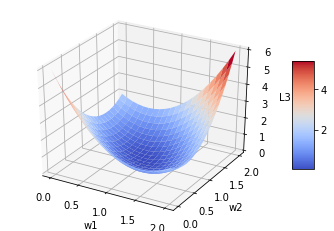

In [19]:
import matplotlib.pyplot as plt
import numpy as np

w1g = np.arange(0,2.01,0.1) # for w_1
w2g = np.arange(0,2.01,0.1) # for w_2
w1gg,w2gg = np.meshgrid(w1g,w2g,sparse=True)
L3 = (w1gg-1)**2 + (w2gg-1)**2 + (w1gg+w2gg-2)**2

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # 要在下一行以前创建axes，否则会出现 MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance
surf = ax.plot_surface(w1gg,w2gg,L3,cmap=cm.coolwarm)
fig.colorbar(surf,shrink=0.5, aspect=5)
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("L3")
plt.show()

The epigraph is:

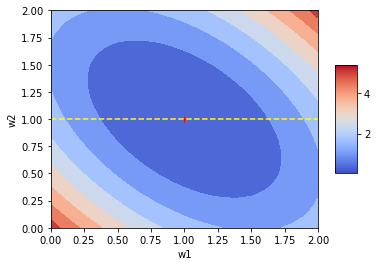

In [32]:
fig,ax = plt.subplots()
fig.colorbar(surf,shrink=0.5, aspect=5)
ax.contourf(w1g,w2g,L3,cmap=cm.coolwarm)
ax.plot(1,1,marker='+',c="red")
ax.axhline(1,c="yellow",linestyle="dashed")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
plt.show()

Its gradient is
$$
    \begin{eqnarray}
    \frac{\delta L_3}{\delta w_1}(\mathbf{w},\mathbf{X}) = 2(w_1 - 1) + 2(w_1 + w_2 - 2) = 4w_1 + 2w_2 - 4 \\
    \frac{\delta L_3}{\delta w_2}(\mathbf{w},\mathbf{X}) = 2(w_2 - 1) + 2(w_1 + w_2 - 2) = 2w_1 + 4w_2 - 4
    \end{eqnarray}
$$

$L_3$ is minimized when its gradient is zero:
$$
    \begin{eqnarray}
        4w_1 + 2w_2 - 4 = 0 \\
        2w_1 + 4w_2 - 4 = 0
    \end{eqnarray}    
$$
Solve for $w_1, w_2$, we have $w_1 = 1, w_2 = 1$. 

The stochastic gradient descent algorithm for training ANN will eventaully find this minimizer.

## $N_2$: the network after dropping first input node, loss is minimized at $w_2 = 1.5$ 

$$ f(\mathbf{x_i},\mathbf{w}) = w_2 x_{i2} $$


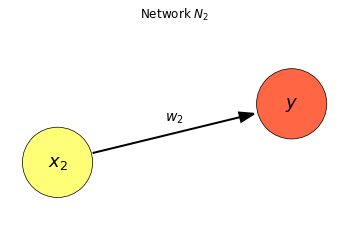

In [25]:
def plotN2():
    # https://viznet.readthedocs.io/en/latest/tutorials.html
    from viznet import NodeBrush, EdgeBrush
    
    brushIn = NodeBrush('nn.input', size='normal')
    brushOut = NodeBrush('nn.output', size='normal')

    n_x2 = brushIn >> (1,1)
    n_x2.text("$x_2$","center", fontsize=18)
    n_y = brushOut >> (3,1.5)
    n_y.text("$y$","center", fontsize=18)

    edge = EdgeBrush('->', lw=2, zorder=1000)
    # connect two nodes
    e_w2 = edge >> (n_x2, n_y)
    e_w2.text('$w_2$', 'top', fontsize=14)

    import matplotlib.pyplot as plt
    plt.title("Network $N_2$")
    plt.axis('off')
    plt.axis('equal')
    plt.show()
    
plotN2()

The loss of $N_2$ on training set is 
$$L_2(\mathbf{w},\mathbf{X}) = (w_2 - 1)^2 + (w_2 - 2)^2$$

Its gradient is
$$
    \frac{\delta L_2}{\delta w_2}(\mathbf{w},\mathbf{X}) = 2(w_2 - 1) + 2(w_2 - 2) = 4w_2 - 6
$$

$L_2$ is minimized at $w_2 = 1.5$


## Relation to VNS


The graph of $L_3$ and $L_2$ along the line $w_1 = 1$:
$$
    \begin{eqnarray}
        L_3(w_2) = 2 (w_2 - 1)^2 \\
        L_2(w_2) = (w_2 - 1)^2 + (w_2 -2)^2
    \end{eqnarray}    
$$

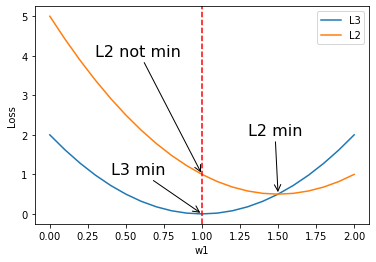

In [33]:
def plotL2L3():
    w1 = 1
    w2g = np.arange(0,2.01,0.1) # for w_2
    L3 = 2 * (w2g-1)**2
    L2 = (w2g-1)**2 + (w2g-2)**2

    fig,ax = plt.subplots()
    ax.plot(w2g,L3,label="L3")#,cmap=cm.coolwarm)
    ax.plot(w2g,L2,label="L2")#,cmap=cm.coolwarm)
    ax.axvline(1,linestyle="dashed",c="red")
    plt.annotate('L3 min', xy=(1, 0), xytext=(0.4, 1),arrowprops=dict(arrowstyle="->"),fontsize=16)
    plt.annotate('L2 not min', xy=(1, 1), xytext=(0.3, 4),arrowprops=dict(arrowstyle="->"),fontsize=16)
    plt.annotate('L2 min', xy=(1.5, 0.5), xytext=(1.3, 2),arrowprops=dict(arrowstyle="->"),fontsize=16)
    ax.set_xlabel("w1")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.show()
plotL2L3()


Consider the following sequence of events
1. Perform SGD to train full network $N_3$, trapped at local optimal $w_1 = 1, w_2 = 1$
2. Switch to network $N_2$, whose loss is not minimum at $w_2 = 1$, SGD will continue to optimize $N_2$ until $w_2 = 1.5$
3. Switch back to full network $N_3$, $w_1 = 1, w_2 = 1.5$ is not local optimal. We escaped from local optimal

Both $N_3$ and $N_2$ can be ssen as defined a neighorhood
